# Kaggle Ames 房价预测：最终实证分析

本笔记用于复核最终结果。完整训练入口是 `final_pipeline.py`，其预处理均在交叉验证折内拟合，避免把验证数据的信息泄露到训练过程。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
DATA_DIR = ROOT.parent
OUTPUT_DIR = ROOT / 'outputs'
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

## 1. 数据与任务

训练集包含房屋属性和 `SalePrice`，测试集隐藏售价。比赛指标等价于对数价格上的 RMSE，因此模型预测的是 `log(SalePrice)`，提交时再转换回美元价格。

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
removed = pd.read_csv(OUTPUT_DIR / 'removed_outliers.csv')

display(pd.DataFrame({
    '数据集': ['train', 'test'],
    '样本数': [len(train), len(test)],
    '字段数': [train.shape[1], test.shape[1]],
    '原始缺失值': [train.isna().sum().sum(), test.isna().sum().sum()],
}))
display(removed[['Id', 'GrLivArea', 'OverallQual', 'SalePrice']])

,数据集,样本数,字段数,原始缺失值
0,train,1460,81,7829
1,test,1459,80,7878


,Id,GrLivArea,OverallQual,SalePrice
0,524,4676,10,184750
1,1299,5642,10,160000


## 2. 建模策略

候选覆盖线性正则、核方法、随机森林、极端随机树、SVR、Gradient Boosting、XGBoost、LightGBM 和 CatBoost。最终只保留经过 OOF 验证且具有互补残差的三个成员。

,model,oof_rmse,fold_std_rmse,elapsed_seconds
0,Lasso,0.110002,0.007457,0.972221
1,ElasticNet,0.110238,0.007465,1.277424
2,Ridge,0.112188,0.008464,0.390892
3,GradientBoosting,0.113885,0.011040,27.870600
4,CatBoost,0.115583,0.007041,628.709499
5,XGBoost,0.116132,0.006683,9.542292
6,LightGBM,0.121283,0.007985,6.009966
7,SVR,0.123243,0.009930,5.409542
8,ExtraTrees,0.130749,0.007953,11.595736
9,RandomForest,0.134390,0.006716,11.018834


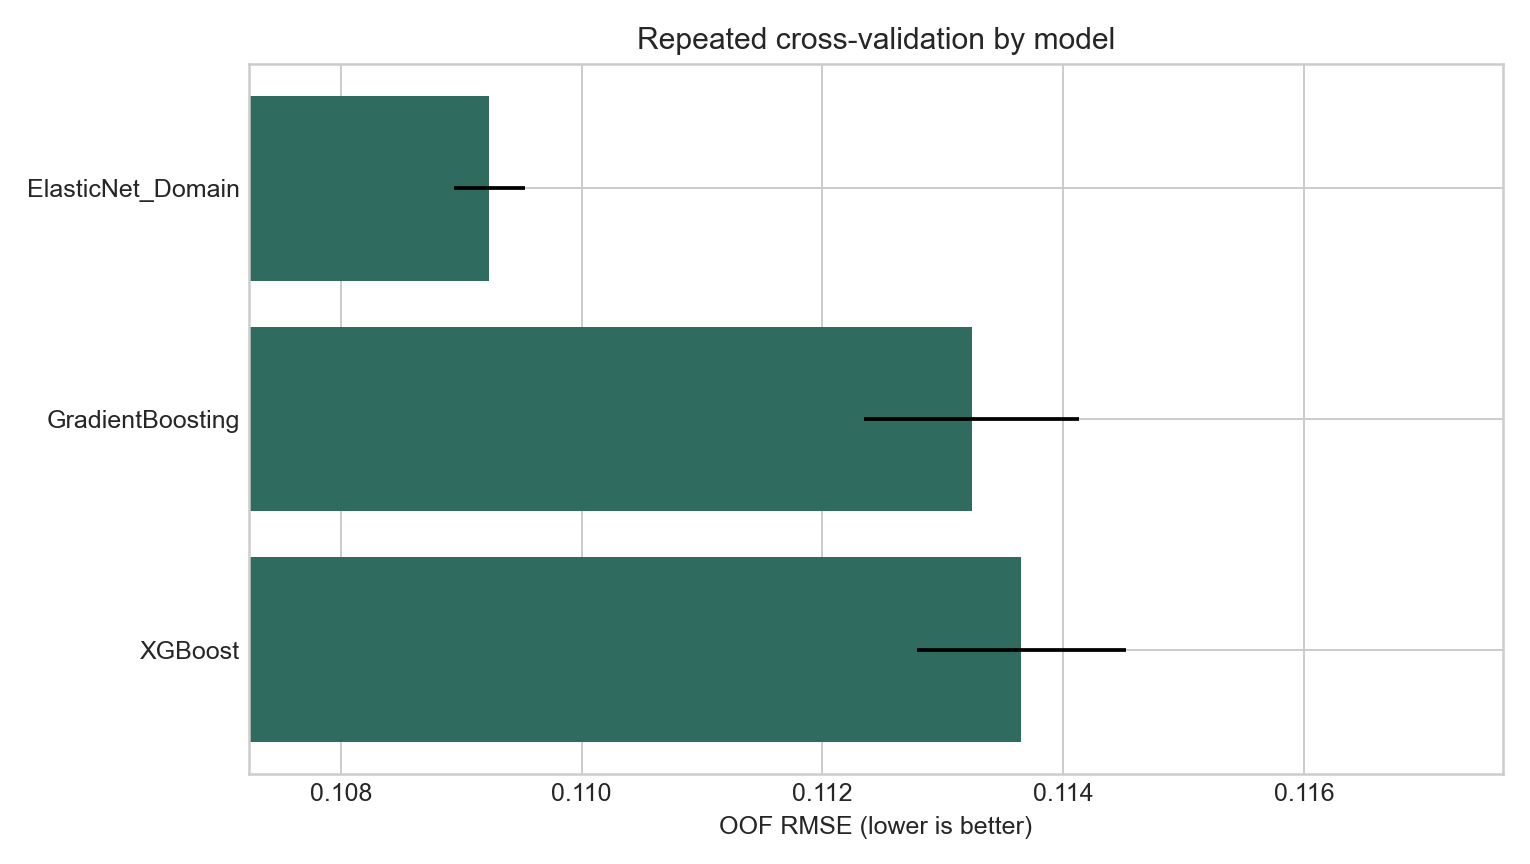

In [3]:
baseline = pd.read_csv(OUTPUT_DIR / 'baseline_models.csv')
display(baseline[['model', 'oof_rmse', 'fold_std_rmse', 'elapsed_seconds']]
        .sort_values('oof_rmse').reset_index(drop=True))
display(Image(filename=str(OUTPUT_DIR / 'model_cv_comparison.png')))

## 3. 重复交叉验证与融合

使用 3 个随机种子、每个种子 5 折，累计得到 15 组折外预测。融合层再使用 8 组随机种子进行二层 5 折验证，并对非负、总和为 1 的权重加入轻微 L2 稳定约束。

In [4]:
model_results = pd.read_csv(OUTPUT_DIR / 'model_results.csv')
blend_results = pd.read_csv(OUTPUT_DIR / 'blend_results.csv')
weights = pd.read_csv(OUTPUT_DIR / 'final_weights.csv')
oof = pd.read_csv(OUTPUT_DIR / 'final_oof_predictions.csv')

summary = (model_results.groupby('model')['oof_rmse']
           .agg(['mean', 'std', 'min', 'max'])
           .sort_values('mean'))
display(summary)
display(blend_results)
display(weights)

verified_rmse = np.sqrt(np.mean(oof['residual_log'] ** 2))
print(f'重新计算的最终 OOF RMSE: {verified_rmse:.10f}')

,mean,std,min,max
model,,,,
ElasticNet_Domain,0.109234,0.000297,0.108995,0.109567
GradientBoosting,0.113240,0.000890,0.112213,0.113762
XGBoost,0.113655,0.000872,0.112848,0.114580


,seed,model,oof_rmse
0,42,CrossFittedBlend,0.106727
1,123,CrossFittedBlend,0.107179
2,2026,CrossFittedBlend,0.106480
3,11,RepeatedMetaCrossFit,0.106065
4,42,RepeatedMetaCrossFit,0.105984
5,123,RepeatedMetaCrossFit,0.105764
6,321,RepeatedMetaCrossFit,0.105775
7,777,RepeatedMetaCrossFit,0.105845
8,999,RepeatedMetaCrossFit,0.105894
9,2026,RepeatedMetaCrossFit,0.105730


,model,weight,crossfit_weight_mean,crossfit_weight_std
0,ElasticNet_Domain,0.418775,0.418728,0.015333
1,GradientBoosting,0.290940,0.290938,0.027395
2,XGBoost,0.290285,0.290334,0.022804


重新计算的最终 OOF RMSE: 0.1056844802


## 4. 测试集预测

`submission.csv` 的 ID、顺序和行数均与 Kaggle 样例一致。价格预测必须为有限正数。

row_count                     1,459.000000
minimum                      44,656.160419
q25                         126,935.509810
median                      156,897.456148
mean                        178,701.322057
q75                         210,433.154339
maximum                     778,529.678756
meta_crossfit_rmse_mean           0.105867
meta_crossfit_rmse_std            0.000115
meta_crossfit_rmse_min            0.105730
meta_crossfit_rmse_max            0.106065
regularized_full_oof_rmse         0.105684
Name: 结果, dtype: float64

,Id,SalePrice
0,1461,"122,441.455161"
1,1462,"158,571.345579"
2,1463,"183,762.120365"
3,1464,"197,811.116708"
4,1465,"189,626.061270"
5,1466,"172,442.977227"
6,1467,"175,858.743714"
7,1468,"164,608.820259"
8,1469,"187,712.452633"
9,1470,"123,173.244561"


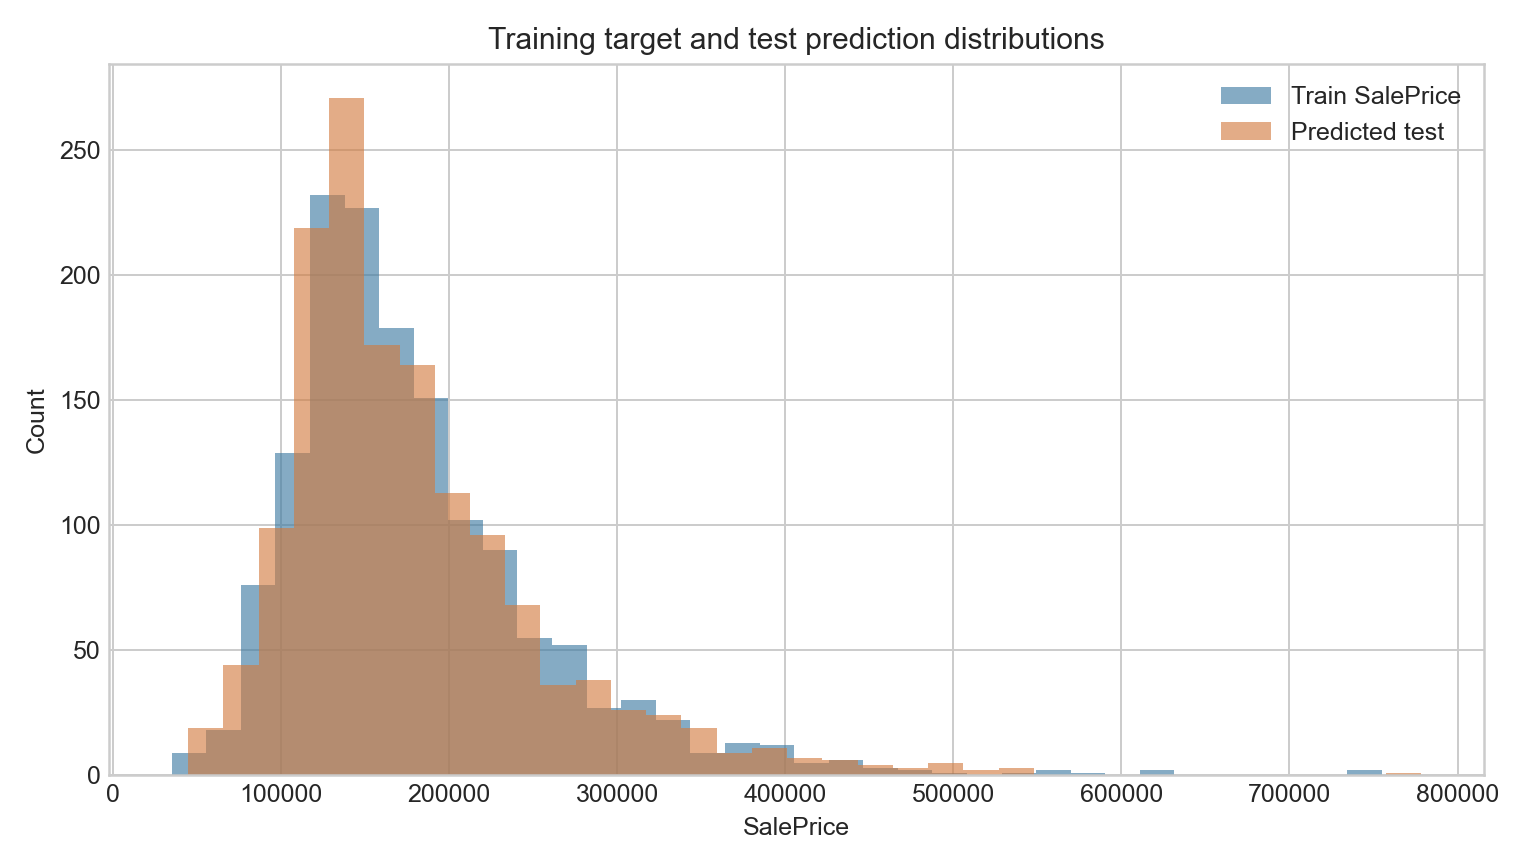

In [5]:
submission = pd.read_csv(OUTPUT_DIR / 'submission.csv')
prediction_summary = json.loads(
    (OUTPUT_DIR / 'prediction_summary.json').read_text(encoding='utf-8')
)
display(pd.Series(prediction_summary, name='结果'))
display(submission.head(10))
display(Image(filename=str(OUTPUT_DIR / 'prediction_distribution.png')))

## 5. 残差诊断与结论

最终融合显著优于各单模型，并通过三轮独立 QA：数据与预处理、提交工件一致性、完整重跑复现。残差图仍显示少数特殊房屋较难预测，这也是隐藏测试误差不可能被保证为零的原因。

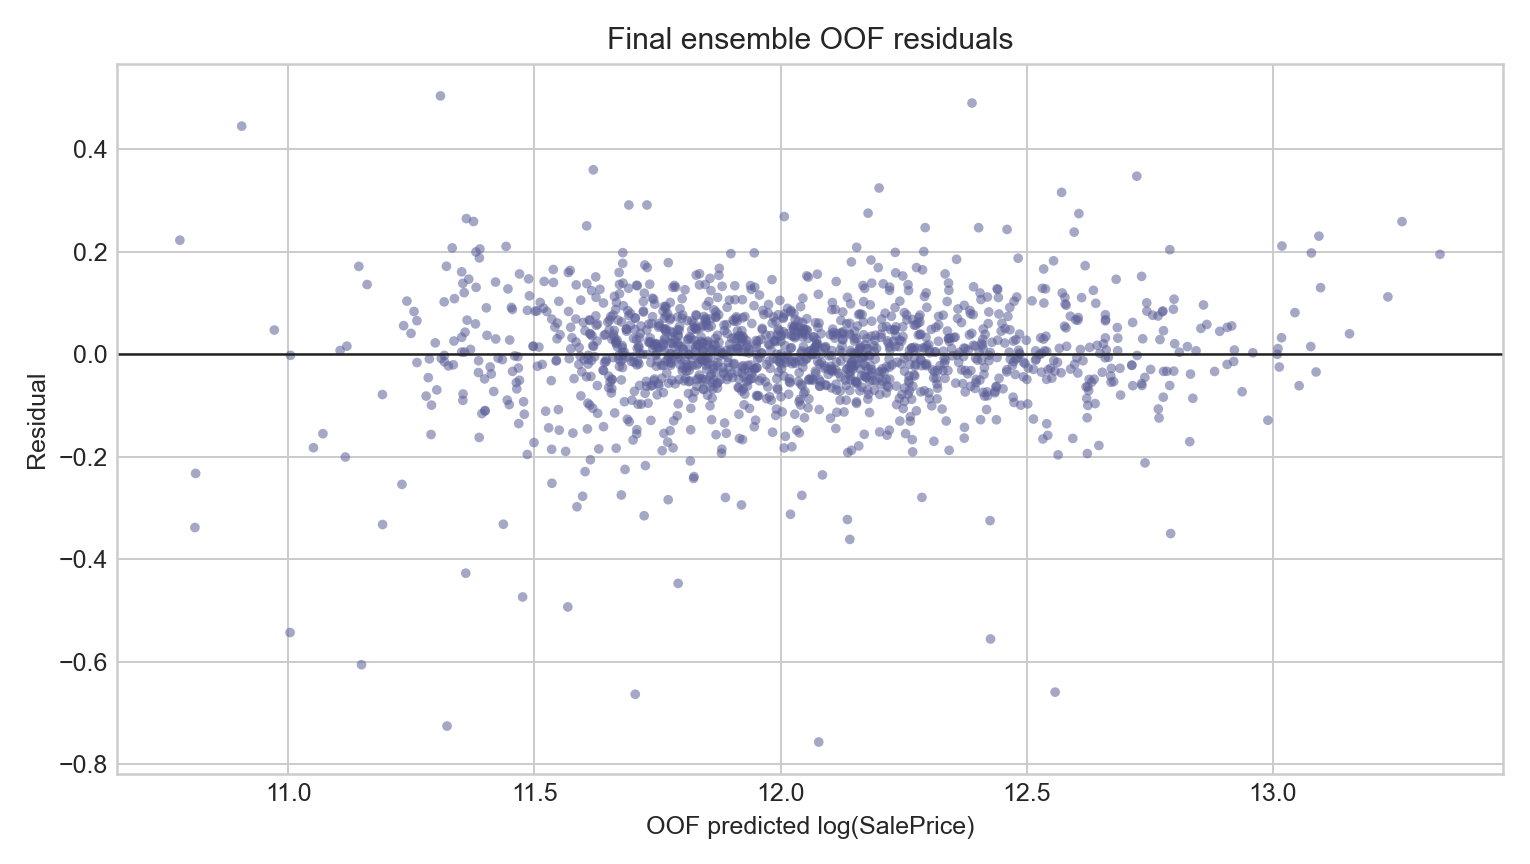

,Id,actual_log_price,ElasticNet_Domain_oof_log,GradientBoosting_oof_log,XGBoost_oof_log,predicted_log_price,residual_log,abs_residual
631,633,11.320554,12.091538,12.064442,12.070183,12.077456,-0.756902,0.756902
30,31,10.596635,11.281581,11.514241,11.188954,11.322383,-0.725748,0.725748
462,463,11.041048,11.685404,11.702911,11.734451,11.704735,-0.663687,0.663687
1322,1325,11.898188,12.558338,12.536571,12.578166,12.557761,-0.659573,0.659573
967,969,10.542706,11.202474,11.100575,11.119344,11.148696,-0.605990,0.605990
587,589,11.870600,12.499124,12.361398,12.386833,12.426458,-0.555858,0.555858
495,496,10.460242,10.900000,11.183476,10.972515,11.003525,-0.543283,0.543283
969,971,11.813030,11.361396,11.266480,11.275994,11.308990,0.504040,0.504040
1430,1433,11.074421,11.517371,11.575403,11.632636,11.567715,-0.493294,0.493294
687,689,12.879017,12.448170,12.341116,12.351098,12.388845,0.490172,0.490172


In [6]:
display(Image(filename=str(OUTPUT_DIR / 'oof_residuals.png')))
largest_errors = oof.assign(abs_residual=oof['residual_log'].abs())
display(largest_errors.nlargest(10, 'abs_residual'))

### 结论边界

8 组二层交叉拟合的平均 RMSE 为 **0.10587**，标准差约 **0.00011**；按最终稳定权重计算的完整 OOF RMSE 为 **0.10568**。Kaggle 隐藏测试标签不可访问，因此这两个数不能冒充真实 test 分数；最终外部表现以 Kaggle 公榜和私榜为准。